In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/custom.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# Chapter 6 — Ensemble Learning Techniques
## Lesson 7: Bias-Variance Reduction via Ensembles

> Fixes included:
> - `OneHotEncoder`: compatible with both `sparse=` and `sparse_output=`
> - `Bagging*`: compatible with both `base_estimator=` and `estimator=`
> - Mermaid diagrams: labels quoted to avoid parse errors


In [2]:
# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modeling
import sklearn
from sklearn.model_selection import (
    train_test_split,
    RepeatedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingRegressor, BaggingClassifier,
    RandomForestRegressor, RandomForestClassifier,
    ExtraTreesRegressor, ExtraTreesClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
)
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Versions:")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)


Versions:
numpy: 2.1.2
pandas: 2.2.3
sklearn: 1.5.2


In [3]:
# Compatibility helpers for scikit-learn API changes across versions.
#
# 1) OneHotEncoder:
#    - Older versions: sparse=
#    - Newer versions: sparse_output=
#
# 2) BaggingClassifier/Regressor:
#    - Older versions: base_estimator=
#    - Newer versions: estimator=
#
# These wrappers make the notebook run across a wider range of sklearn versions.

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        # Older sklearn
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

def make_bagging_regressor(base_estimator, n_estimators=300, bootstrap=True, random_state=42, n_jobs=-1):
    try:
        return BaggingRegressor(
            estimator=base_estimator,
            n_estimators=n_estimators,
            bootstrap=bootstrap,
            random_state=random_state,
            n_jobs=n_jobs,
        )
    except TypeError:
        return BaggingRegressor(
            base_estimator=base_estimator,
            n_estimators=n_estimators,
            bootstrap=bootstrap,
            random_state=random_state,
            n_jobs=n_jobs,
        )

def make_bagging_classifier(base_estimator, n_estimators=300, bootstrap=True, random_state=42, n_jobs=-1):
    try:
        return BaggingClassifier(
            estimator=base_estimator,
            n_estimators=n_estimators,
            bootstrap=bootstrap,
            random_state=random_state,
            n_jobs=n_jobs,
        )
    except TypeError:
        return BaggingClassifier(
            base_estimator=base_estimator,
            n_estimators=n_estimators,
            bootstrap=bootstrap,
            random_state=random_state,
            n_jobs=n_jobs,
        )

print("Compatibility helpers loaded.")


Compatibility helpers loaded.


In [4]:
def read_csv_safe(path, **kwargs):
    # Read a CSV using pandas with a helpful message if the file is missing.
    # The repository structure assumes paths like:
    #   ../../../Datasets/Classification/diabetes.csv
    try:
        df = pd.read_csv(path, **kwargs)
        print(f"Loaded: {path}  shape={df.shape}")
        return df
    except FileNotFoundError:
        print(f"[FileNotFoundError] Could not find: {path}")
        print("Check that your repo has the Datasets/ folder at the root, and that this notebook is located at:")
        print("  Tutorials/(English|Persian)/Chapter6/")
        return None

# Dataset paths (relative to Tutorials/*/Chapter6/)
PATH_DIABETES = "../../../Datasets/Classification/diabetes.csv"
PATH_DRUG200  = "../../../Datasets/Classification/drug200.csv"
PATH_IRIS     = "../../../Datasets/Classification/iris.csv"

PATH_HOUSE    = "../../../Datasets/Regression/house-prices.csv"
PATH_COGN     = "../../../Datasets/Regression/cognitive.csv"
PATH_DIAMONDS = "../../../Datasets/Regression/diamonds.csv"


---

## 1) Motivation and theory (high-level)

Ensembles reduce **variance** mainly by averaging multiple models and reducing correlation among them.

Key regression decomposition (squared loss):

$$
\mathbb{E}\Big[(Y - \hat f_D(x))^2\Big]
=
\big(\mathbb{E}[\hat f_D(x)] - f(x)\big)^2
+
\mathbb{E}\Big[(\hat f_D(x) - \mathbb{E}[\hat f_D(x)])^2\Big]
+
\sigma^2(x)
$$

Variance of the average of $M$ equally-variant predictors with pairwise correlation $\rho$:

$$
\mathrm{Var}(\bar Z)
=
\sigma^2\left(\rho + \frac{1-\rho}{M}\right)
$$


---

## 2) Where does diversity come from?

```mermaid
flowchart TD
  D["Training data D"] --> B1["Bootstrap sample D(1)"]
  D --> B2["Bootstrap sample D(2)"]
  D --> B3["Bootstrap sample D(M)"]
  B1 --> T1["Train base learner"]
  B2 --> T2["Train base learner"]
  B3 --> TM["Train base learner"]
  T1 --> A["Aggregate: mean or vote"]
  T2 --> A
  TM --> A
  A --> P["Final predictor"]
```

```mermaid
flowchart LR
  X["Need variance reduction"] --> C1["Increase M (number of estimators)"]
  X --> C2["Decrease correlation ρ"]
  C2 --> F1["Feature randomness (Random Forest)"]
  C2 --> F2["Split randomness (ExtraTrees)"]
  C2 --> D1["Data randomness (bootstrap)"]
```


---

## 3) Datasets used in this lesson

Random selection (multiple datasets):

- Classification: `diabetes.csv`, `drug200.csv`
- Regression: `house-prices.csv`, `cognitive.csv`

Paths are relative to `Tutorials/*/Chapter6/`:
`../../../Datasets/...`


In [5]:
# Quick peek at a few datasets (chosen "randomly" for this lesson: 2 classification + 2 regression)
df_diabetes = read_csv_safe(PATH_DIABETES)
df_drug200  = read_csv_safe(PATH_DRUG200)
df_house    = read_csv_safe(PATH_HOUSE)
df_cogn     = read_csv_safe(PATH_COGN)

for name, df in [("diabetes", df_diabetes), ("drug200", df_drug200), ("house-prices", df_house), ("cognitive", df_cogn)]:
    if df is not None:
        print("\n---", name, "---")
        display(df.head())


Loaded: ../../../Datasets/Classification/diabetes.csv  shape=(768, 9)
Loaded: ../../../Datasets/Classification/drug200.csv  shape=(200, 6)
Loaded: ../../../Datasets/Regression/house-prices.csv  shape=(128, 8)
Loaded: ../../../Datasets/Regression/cognitive.csv  shape=(434, 5)

--- diabetes ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic



--- drug200 ---


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY



--- house-prices ---


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East



--- cognitive ---


,kid_score,mom_hs,mom_iq,mom_work,mom_age
0,65,yes,121.117529,yes,27
1,98,yes,89.361882,yes,25
2,85,yes,115.443165,yes,27
3,83,yes,99.449639,yes,25
4,115,yes,92.745710,yes,27


---

## 4) Synthetic bias–variance experiment

Run the next code cell.

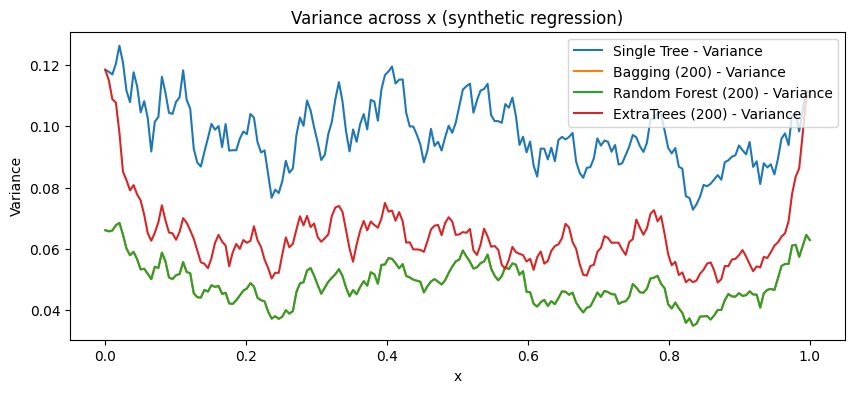

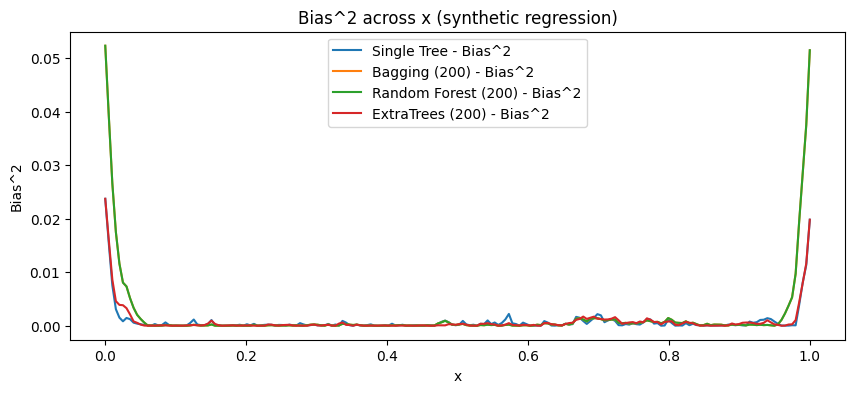

,Model,Avg Bias^2,Avg Variance,Noise (sigma^2),Avg MSE
1,Bagging (200),0.001898,0.048488,0.09,0.140386
2,Random Forest (200),0.001898,0.048488,0.09,0.140386
3,ExtraTrees (200),0.000826,0.064322,0.09,0.155148
0,Single Tree,0.000800,0.097626,0.09,0.188426


In [6]:
# Empirical bias-variance decomposition for squared loss (regression)

def f_true(x):
    return np.sin(2*np.pi*x)

def sample_dataset(n=40, sigma=0.3, rng=None):
    rng = np.random.default_rng(rng)
    X = rng.uniform(0, 1, size=(n, 1))
    y = f_true(X[:, 0]) + rng.normal(0, sigma, size=n)
    return X, y

def bias_variance_curve(model_factory, n_train=40, sigma=0.3, n_trials=200, grid_size=200, rng=0):
    rng = np.random.default_rng(rng)
    x_grid = np.linspace(0, 1, grid_size)
    preds = np.zeros((n_trials, grid_size), dtype=float)

    for t in range(n_trials):
        X, y = sample_dataset(n=n_train, sigma=sigma, rng=rng.integers(0, 10**9))
        model = model_factory()
        model.fit(X, y)
        preds[t, :] = model.predict(x_grid.reshape(-1, 1))

    f = f_true(x_grid)
    mean_pred = preds.mean(axis=0)
    bias2 = (mean_pred - f)**2
    var = preds.var(axis=0)
    noise = sigma**2 * np.ones_like(x_grid)
    mse = bias2 + var + noise
    return x_grid, f, bias2, var, noise, mse

def make_tree():
    return DecisionTreeRegressor(max_depth=None, random_state=RANDOM_STATE)

def make_bagging(M=200):
    return make_bagging_regressor(
        base_estimator=DecisionTreeRegressor(max_depth=None, random_state=RANDOM_STATE),
        n_estimators=M,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

def make_rf(M=200):
    return RandomForestRegressor(
        n_estimators=M,
        max_features="sqrt",
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

def make_et(M=200):
    return ExtraTreesRegressor(
        n_estimators=M,
        max_features="sqrt",
        bootstrap=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

models = {
    "Single Tree": make_tree,
    "Bagging (200)": lambda: make_bagging(200),
    "Random Forest (200)": lambda: make_rf(200),
    "ExtraTrees (200)": lambda: make_et(200),
}

results = {}
for name, mf in models.items():
    xg, f, b2, v, n, mse = bias_variance_curve(mf, n_train=40, sigma=0.3, n_trials=250, rng=123)
    results[name] = (xg, f, b2, v, n, mse)

plt.figure(figsize=(10, 4))
for name, (xg, f, b2, v, n, mse) in results.items():
    plt.plot(xg, v, label=f"{name} - Variance")
plt.title("Variance across x (synthetic regression)")
plt.xlabel("x")
plt.ylabel("Variance")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
for name, (xg, f, b2, v, n, mse) in results.items():
    plt.plot(xg, b2, label=f"{name} - Bias^2")
plt.title("Bias^2 across x (synthetic regression)")
plt.xlabel("x")
plt.ylabel("Bias^2")
plt.legend()
plt.show()

summary_rows = []
for name, (xg, f, b2, v, n, mse) in results.items():
    summary_rows.append({
        "Model": name,
        "Avg Bias^2": float(b2.mean()),
        "Avg Variance": float(v.mean()),
        "Noise (sigma^2)": float(n.mean()),
        "Avg MSE": float(mse.mean()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Avg MSE")
display(summary_df)


---

## 5) Correlation formula verification

Run the next code cell.

In [7]:
# Demonstrating the variance reduction formula with correlated base learners

def simulate_correlated(M=50, rho=0.2, n_samples=20000, rng=0):
    rng = np.random.default_rng(rng)
    Sigma = (1 - rho) * np.eye(M) + rho * np.ones((M, M))
    Z = rng.multivariate_normal(mean=np.zeros(M), cov=Sigma, size=n_samples)
    avg = Z.mean(axis=1)
    return avg.var()

for rho in [0.0, 0.2, 0.5, 0.8]:
    for M in [1, 5, 20, 100]:
        emp = simulate_correlated(M=M, rho=rho, rng=123)
        theo = 1.0 * (rho + (1-rho)/M)  # sigma^2=1
        print(f"rho={rho:0.1f}, M={M:3d}  empirical={emp:0.4f}  theory={theo:0.4f}")


rho=0.0, M=  1  empirical=0.9976  theory=1.0000
rho=0.0, M=  5  empirical=0.1982  theory=0.2000
rho=0.0, M= 20  empirical=0.0490  theory=0.0500
rho=0.0, M=100  empirical=0.0099  theory=0.0100
rho=0.2, M=  1  empirical=0.9976  theory=1.0000
rho=0.2, M=  5  empirical=0.3583  theory=0.3600
rho=0.2, M= 20  empirical=0.2412  theory=0.2400
rho=0.2, M=100  empirical=0.2104  theory=0.2080
rho=0.5, M=  1  empirical=0.9976  theory=1.0000
rho=0.5, M=  5  empirical=0.5972  theory=0.6000
rho=0.5, M= 20  empirical=0.5276  theory=0.5250
rho=0.5, M=100  empirical=0.5107  theory=0.5050
rho=0.8, M=  1  empirical=0.9976  theory=1.0000
rho=0.8, M=  5  empirical=0.8361  theory=0.8400
rho=0.8, M= 20  empirical=0.8140  theory=0.8100
rho=0.8, M=100  empirical=0.8111  theory=0.8020


---

## 6) Real-data instability: regression

Run the next code cell.

Loaded: ../../../Datasets/Regression/house-prices.csv  shape=(128, 8)


,Model,RMSE mean,RMSE std (instability),RMSE min,RMSE max
2,RandomForest,12826.949743,1901.134997,7233.869997,17763.270900
4,GradientBoosting,12952.667638,1896.909475,8124.179074,18218.973135
1,Bagging,13188.494296,1814.963783,8291.219661,18145.855880
3,ExtraTrees,13594.656560,1760.018828,8586.029141,17807.747193
0,Tree,18067.534661,2722.764807,11499.704344,25778.837475


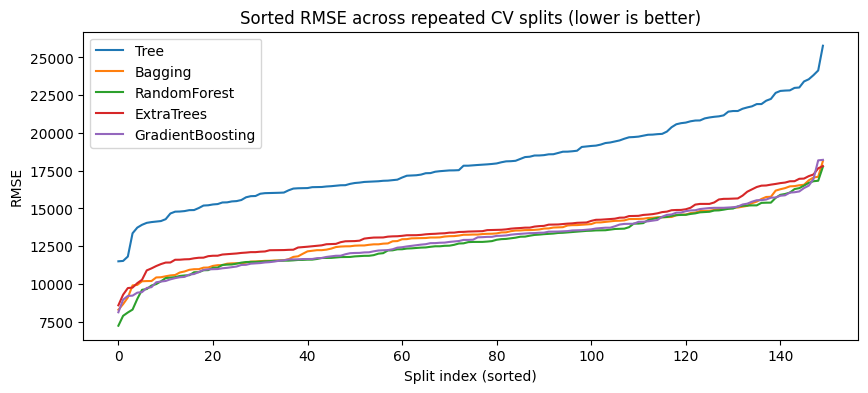

In [8]:
# Real-data regression example: house-prices.csv

df_house = read_csv_safe(PATH_HOUSE)
if df_house is not None:
    target = "Price"
    X = df_house.drop(columns=[target])
    y = df_house[target].astype(float)

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder()),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop",
    )

    models = {
        "Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "Bagging": make_bagging_regressor(
            base_estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
            n_estimators=300, bootstrap=True, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "RandomForest": RandomForestRegressor(
            n_estimators=400, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1
        ),
        "ExtraTrees": ExtraTreesRegressor(
            n_estimators=400, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1
        ),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    }

    rkf = RepeatedKFold(n_splits=5, n_repeats=30, random_state=RANDOM_STATE)

    rows = []
    for name, model in models.items():
        pipe = Pipeline(steps=[("pre", pre), ("model", model)])
        scores = cross_val_score(pipe, X, y, cv=rkf, scoring="neg_root_mean_squared_error", n_jobs=-1)
        rmse = -scores
        rows.append({
            "Model": name,
            "RMSE mean": float(rmse.mean()),
            "RMSE std (instability)": float(rmse.std(ddof=1)),
            "RMSE min": float(rmse.min()),
            "RMSE max": float(rmse.max()),
        })

    res = pd.DataFrame(rows).sort_values("RMSE mean")
    display(res)

    plt.figure(figsize=(10, 4))
    for name, model in models.items():
        pipe = Pipeline(steps=[("pre", pre), ("model", model)])
        scores = cross_val_score(pipe, X, y, cv=rkf, scoring="neg_root_mean_squared_error", n_jobs=-1)
        rmse = -scores
        plt.plot(np.sort(rmse), label=name)
    plt.title("Sorted RMSE across repeated CV splits (lower is better)")
    plt.xlabel("Split index (sorted)")
    plt.ylabel("RMSE")
    plt.legend()
    plt.show()


---

## 7) Real-data instability: classification

Run the next code cell.

In [9]:
# Real-data classification example: diabetes.csv + drug200.csv

def evaluate_classifier(df, target_col, title):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder()),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop",
    )

    models = {
        "Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "Bagging": make_bagging_classifier(
            base_estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            n_estimators=300, bootstrap=True, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=400, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1
        ),
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=400, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1
        ),
        "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    }

    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=RANDOM_STATE)

    rows = []
    for name, model in models.items():
        pipe = Pipeline(steps=[("pre", pre), ("model", model)])
        scores = cross_val_score(pipe, X, y, cv=rskf, scoring="accuracy", n_jobs=-1)
        rows.append({
            "Model": name,
            "Accuracy mean": float(scores.mean()),
            "Accuracy std (instability)": float(scores.std(ddof=1)),
            "Accuracy min": float(scores.min()),
            "Accuracy max": float(scores.max()),
        })

    res = pd.DataFrame(rows).sort_values("Accuracy mean", ascending=False)
    print("\n", title)
    display(res)

df_diabetes = read_csv_safe(PATH_DIABETES)
if df_diabetes is not None:
    evaluate_classifier(df_diabetes, target_col="classification", title="diabetes.csv (binary)")

df_drug200 = read_csv_safe(PATH_DRUG200)
if df_drug200 is not None:
    evaluate_classifier(df_drug200, target_col="Drug", title="drug200.csv (multiclass)")


Loaded: ../../../Datasets/Classification/diabetes.csv  shape=(768, 9)

 diabetes.csv (binary)


,Model,Accuracy mean,Accuracy std (instability),Accuracy min,Accuracy max
2,RandomForest,0.765282,0.029771,0.692810,0.831169
3,ExtraTrees,0.762872,0.029725,0.699346,0.824675
1,Bagging,0.761824,0.031204,0.679739,0.837662
4,GradientBoosting,0.758316,0.027518,0.660131,0.811688
0,Tree,0.702787,0.033740,0.620915,0.785714


Loaded: ../../../Datasets/Classification/drug200.csv  shape=(200, 6)

 drug200.csv (multiclass)


,Model,Accuracy mean,Accuracy std (instability),Accuracy min,Accuracy max
2,RandomForest,0.99075,0.015347,0.925,1.0
0,Tree,0.98950,0.016353,0.950,1.0
1,Bagging,0.98950,0.016353,0.950,1.0
4,GradientBoosting,0.97900,0.025554,0.875,1.0
3,ExtraTrees,0.94375,0.037331,0.850,1.0


---

## 8) Bagging from scratch

Run the next code cell.

In [10]:
# Bagging "from scratch" (minimal educational implementation)

from collections import Counter
from sklearn.datasets import make_classification

class SimpleBaggingClassifier:
    def __init__(self, base_estimator_factory, n_estimators=100, bootstrap=True, random_state=42):
        self.base_estimator_factory = base_estimator_factory
        self.n_estimators = n_estimators
        self.bootstrap = bootstrap
        self.random_state = random_state
        self.models_ = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X = np.asarray(X)
        y = np.asarray(y)
        n = X.shape[0]
        self.models_ = []
        for _ in range(self.n_estimators):
            idx = rng.integers(0, n, size=n) if self.bootstrap else rng.permutation(n)
            model = self.base_estimator_factory()
            model.fit(X[idx], y[idx])
            self.models_.append(model)
        return self

    def predict(self, X):
        X = np.asarray(X)
        all_preds = np.vstack([m.predict(X) for m in self.models_])
        out = []
        for j in range(all_preds.shape[1]):
            out.append(Counter(all_preds[:, j]).most_common(1)[0][0])
        return np.array(out)

X, y = make_classification(
    n_samples=2000, n_features=10, n_informative=4, n_redundant=0,
    flip_y=0.05, class_sep=1.0, random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
bag = SimpleBaggingClassifier(lambda: DecisionTreeClassifier(random_state=RANDOM_STATE),
                              n_estimators=200, random_state=RANDOM_STATE)

tree.fit(X_train, y_train)
bag.fit(X_train, y_train)

print("Single Tree accuracy:", accuracy_score(y_test, tree.predict(X_test)))
print("SimpleBagging accuracy:", accuracy_score(y_test, bag.predict(X_test)))


Single Tree accuracy: 0.794
SimpleBagging accuracy: 0.874


---

## 9) Exercises

Run the last cell.

In [11]:
# Exercises (optional to run):
#
# 1) Change tree depth and observe bias/variance behavior in the synthetic decomposition.
# 2) Increase/decrease n_estimators for bagging/RF/ExtraTrees and see how instability changes.
# 3) For RandomForest, vary max_features to see the diversity (correlation) effect on performance variance.
# 4) Replace DecisionTree with a stable learner (e.g., linear regression) in BaggingRegressor and observe: variance reduction is small.
#
# Tip: start with small repeats, then increase for smoother results.

print("Exercises cell: nothing to run by default.")


Exercises cell: nothing to run by default.
